In [1]:
from brainwidemap.decoding.functions.process_inputs import select_ephys_regions
from brainwidemap.decoding.functions.process_inputs import preprocess_ephys
from brainwidemap.decoding.functions.process_targets import compute_beh_target
from brainwidemap.decoding.functions.process_targets import compute_target_mask
from brainwidemap.decoding.functions.process_targets import transform_data_for_decoding
from brainwidemap.decoding.functions.process_targets import logisticreg_criteria
from brainwidemap.decoding.functions.process_targets import get_target_data_per_trial_wrapper

from brainbox.io.one import SessionLoader
import matplotlib.pyplot as plt
import numpy as np
from one.api import ONE
from pathlib import Path
import pickle

from brainwidemap.bwm_loading import bwm_query, load_good_units, load_trials_and_mask
from brainwidemap.decoding.functions.decoding import fit_eid
from brainwidemap.decoding.functions.utils import get_save_path
from brainwidemap.decoding.settings_template import params

from ibl_info.prepare_data_pid import get_new_cinc_intervals, prepare_ephys_data
from one.api import ONE

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from sklearn.ensemble import RandomForestClassifier
from ibl_info.prepare_data_pid import (
    cleaned_regions_flags,
    get_new_cinc_intervals,
    prepare_ephys_data,
)
from ibl_info.utils import (
    alternate_discretize,
    compute_mutual_information,
    compute_pid,
    compute_trivariate_mi,
    FIRING_RATE,
    discretize,
    discretize_keeping_zeros,
    equipopulated_binning,
)
import os
import concurrent.futures
import functools
import random
from ibl_info.utils import check_config

In [2]:
%load_ext autoreload
%autoreload 2

In [11]:
# connect to server
one = ONE(
    base_url="https://openalyx.internationalbrainlab.org", password="international", silent=True
)
# select example eid for decoding analysis
subject_id = "CSH_ZAD_022"
eid = "a82800ce-f4e3-4464-9b80-4c3d6fade333"
session_id = eid

In [1]:
# compare decoders using null distributions

In [27]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import roc_auc_score

# Define models and their hyperparameter grids
# --- Linear Model: Logistic Regression ---
lr_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                solver="liblinear",
                random_state=42,
                max_iter=20000,
                tol=0.0001,
                fit_intercept=True,
            ),
        ),
    ]
)
lr_params = {"clf__C": [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10]}
# --- Nonlinear Model: Random Forest ---
rf_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")),
    ]
)
# Parameters are chosen to prevent overfitting on small datasets.
rf_params = {
    "clf__n_estimators": [50, 150],
    "clf__max_depth": [3, 7],
    "clf__min_samples_leaf": [10],
    "clf__max_features": ["sqrt"],
}

# Store models and params in a dictionary for easy iteration
models = {"Logistic Regression": (lr_pipe, lr_params), "Random Forest": (rf_pipe, rf_params)}

In [28]:
def get_performance_and_null_distribution(X, y, pipeline, param_grid, n_permutations=10):
    """
    Performs nested CV to get the real score and permutation testing
    to get the null distribution of scores.
    """
    # --- Cross-Validation Setup ---
    # Inner CV for hyperparameter tuning
    inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    # Outer CV for performance estimation
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # --- 1. Calculate Real Performance Score ---
    real_scores = []
    for train_idx, test_idx in outer_cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Inner loop for hyperparameter tuning
        grid_search = GridSearchCV(
            estimator=pipeline, param_grid=param_grid, cv=inner_cv, scoring="roc_auc"
        )
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_

        # Evaluate on the outer test set
        y_pred_proba = best_model.predict_proba(X_test)[:, 1]
        score = roc_auc_score(y_test, y_pred_proba)
        real_scores.append(score)

    real_performance = np.mean(real_scores)

    # --- 2. Generate Null Distribution via Permutation Testing ---
    null_scores = []
    for i in range(n_permutations):
        print(f"Running permutation {i+1}/{n_permutations}...", end="\r")
        y_permuted = np.random.permutation(y)

        permuted_run_scores = []
        for train_idx, test_idx in outer_cv.split(X, y_permuted):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train_p, y_test_p = y_permuted[train_idx], y_permuted[test_idx]

            grid_search = GridSearchCV(
                estimator=pipeline, param_grid=param_grid, cv=inner_cv, scoring="roc_auc"
            )
            grid_search.fit(X_train, y_train_p)
            best_model = grid_search.best_estimator_

            y_pred_proba = best_model.predict_proba(X_test)[:, 1]
            score = roc_auc_score(y_test_p, y_pred_proba)
            permuted_run_scores.append(score)

        null_scores.append(np.mean(permuted_run_scores))

    print("\nDone.")
    return real_performance, np.array(null_scores)

In [29]:
# just get X and y now

In [15]:
session_id = eid
pids, probes = one.eid2pid(session_id)
if isinstance(probes, list) and len(probes) > 1:
    to_merge = [load_good_units(one, pid=pid, qc=1) for pid in pids]
    spikes, clusters = merge_probes(
        [spikes for spikes, _ in to_merge], [clusters for _, clusters in to_merge]
    )
else:
    spikes, clusters = load_good_units(one, pid=pids[0], qc=1)

trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)
trials = trials[mask]

intervals, target_variable, congruent_flags, incongruent_flags = get_new_cinc_intervals(
    trials, "stim"
)

binned_spikes, actual_regions, n_units, cluster_uuids_list = prepare_ephys_data(
    spikes, clusters, intervals, ["LGd"], minimum_units=5
)  # this returns all neurons from a single region that pass qc
# however, it is in trials x neurons

spike_data = binned_spikes[0].T

congruent_target = target_variable[congruent_flags]
incongruent_target = target_variable[incongruent_flags]

congruent_spikes = spike_data[:, congruent_flags].T
incongruent_spikes = spike_data[:, incongruent_flags].T

Region found LGd, 67


In [58]:
def get_effect_size_for_condition(X, y, model_name, models_to_run, n_perms):
    pipeline, params = models_to_run[model_name]

    real_score, null_dist = get_performance_and_null_distribution(
        X, y, pipeline, params, n_permutations=n_perms
    )

    mean_null = np.mean(null_dist)
    std_null = np.std(null_dist)
    effect_size = (real_score - mean_null) / std_null if std_null > 0 else 0.0

    return effect_size

In [31]:
import warnings

warnings.filterwarnings("ignore")

In [64]:
def subsampled(congruent_spikes, congruent_targets, incongruent_targets, n_repeats=5):

    left_fraction = np.sum(incongruent_targets == 1) / len(incongruent_targets)

    # we want to ensure similar fraction for congruent subsampling
    left_congruent = np.where(congruent_targets == 1)[0]
    right_congruent = np.where(congruent_targets == 0)[0]

    for _ in range(n_repeats):
        n_left_subsample = int(np.round(left_fraction * len(incongruent_targets)))
        n_right_subsample = int(len(incongruent_targets) - n_left_subsample)

        # now we need to do the actual subsampling
        selected_indices_left = np.random.choice(left_congruent, n_left_subsample, replace=False)
        selected_indices_right = np.random.choice(
            right_congruent, n_right_subsample, replace=False
        )

        selected_indices = np.concatenate((selected_indices_left, selected_indices_right))
        subsampled_targets = congruent_targets[selected_indices]
        subsampled_spikes = congruent_spikes[selected_indices, :]

        yield subsampled_targets, subsampled_spikes

In [54]:
N_PERMUTATIONS = 10
# to make things quick


def define_models_and_parameters():
    """
    Defines the scikit-learn pipelines and hyperparameter grids for each model.
    Returns a dictionary of models to be evaluated.
    """

    # --- Linear Model: Logistic Regression ---
    lr_pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(solver="liblinear", random_state=42, class_weight="balanced"),
            ),
        ]
    )
    # Note the 'clf__' prefix to target the classifier step in the pipeline
    lr_params = {"clf__C": np.logspace(-3, 3, 7)}  # Regularization strength

    # --- Nonlinear Model: Random Forest ---
    rf_pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced")),
        ]
    )
    # Parameters are chosen to prevent overfitting on small datasets
    rf_params = {
        "clf__n_estimators": [50, 150],
        "clf__max_depth": [3, 7],
        "clf__min_samples_leaf": [3, 10],
        "clf__max_features": ["sqrt"],
    }

    # The final dictionary that will be returned
    models = {"Logistic Regression": (lr_pipe, lr_params), "Random Forest": (rf_pipe, rf_params)}
    return models

In [55]:
models_to_run = define_models_and_parameters()

In [59]:
d_LR_incongruent = get_effect_size_for_condition(
    incongruent_spikes, incongruent_target, "Logistic Regression", models_to_run, N_PERMUTATIONS
)

Running permutation 10/10...
Done.


In [60]:
d_RF_incongruent = get_effect_size_for_condition(
    incongruent_spikes, incongruent_target, "Random Forest", models_to_run, N_PERMUTATIONS
)

Running permutation 10/10...
Done.


In [65]:
print("\nAnalyzing subsamples of congruent trials...")
d_LR_congruent_iterations = []
d_RF_congruent_iterations = []

# Use your generator to create balanced subsamples
subsample_generator = subsampled(
    congruent_spikes, congruent_target, incongruent_target, n_repeats=3
)

for i, (targets_sub, spikes_sub) in enumerate(subsample_generator):
    print(f"  Processing congruent subsample {i+1}/3...")

    # Analyze each subsample and store the effect size
    d_lr = get_effect_size_for_condition(
        spikes_sub, targets_sub, "Logistic Regression", models_to_run, N_PERMUTATIONS
    )
    d_rf = get_effect_size_for_condition(
        spikes_sub, targets_sub, "Random Forest", models_to_run, N_PERMUTATIONS
    )

    d_LR_congruent_iterations.append(d_lr)
    d_RF_congruent_iterations.append(d_rf)

# --- C. Average the results for the congruent category ---
d_LR_congruent_stable = np.mean(d_LR_congruent_iterations)
d_RF_congruent_stable = np.mean(d_RF_congruent_iterations)
delta_d_congruent = d_RF_congruent_stable - d_LR_congruent_stable


Analyzing subsamples of congruent trials...
  Processing congruent subsample 1/5...
Running permutation 10/10...
Done.
Running permutation 10/10...
Done.
  Processing congruent subsample 2/5...
Running permutation 10/10...
Done.
Running permutation 10/10...
Done.
  Processing congruent subsample 3/5...
Running permutation 10/10...
Done.
Running permutation 10/10...
Done.


In [66]:
delta_d_congruent

np.float64(1.1294928053874949)

In [67]:
delta_d_incongruent = d_RF_incongruent - d_LR_incongruent

In [68]:
delta_d_incongruent

np.float64(3.9605721401738214)

In [75]:
one.alyx.user

'intbrainlab'

In [ ]:
subject_ids_trained = [1, 2]

In [78]:
training_sessions = np.asarray([2, 3, 5, 29, 15, 10, 7, 20, 17, 6, 3, 1, 1])
trained_sessions = np.asarray([2, 5, 1, 9, 2, 13, 13, 9, 12, 5, 2, 9, 0])

In [119]:
# load up


def compute_final_metric(data):
    final_metric = []
    for k in data.keys():
        if (
            data[k]["d_RF_incongruent"] <= 0
            or data[k]["d_RF_congruent"] <= 0
            or data[k]["d_LR_congruent"] <= 0
            or data[k]["d_LR_congruent"] <= 0
        ):
            print(data[k])
            continue
        final_metric.append(data[k]["final_metric"])
    return np.asarray(final_metric)

In [120]:
with open("../data/generated/nulldecoders/decoder_null_delta_IRN_.pkl", "rb") as f:
    IRN_data = pkl.load(f)

with open("../data/generated/nulldecoders/decoder_null_delta_VISp_.pkl", "rb") as f:
    VISp_data = pkl.load(f)

In [121]:
fm_irn = compute_final_metric(IRN_data)
fm_visp = compute_final_metric(VISp_data)

{'session_id': '037d75ca-c90a-43f2-aca6-e86611916779', 'd_LR_incongruent': np.float64(-0.9000168728354702), 'd_RF_incongruent': np.float64(-0.8159998381194192), 'd_LR_congruent': np.float64(1.7041730704355855), 'd_RF_congruent': np.float64(1.8003855718525754), 'nonlin_advantage_incongruent': np.float64(0.08401703471605093), 'nonlin_advantage_congruent': np.float64(0.09621250141698989), 'final_metric': np.float64(-0.012195466700938962)}
{'session_id': '20c112a1-8a42-44e0-a4cd-e5b932f7bda9', 'd_LR_incongruent': np.float64(0.18601434684730808), 'd_RF_incongruent': np.float64(0.21183353854963866), 'd_LR_congruent': np.float64(0.953602885060722), 'd_RF_congruent': np.float64(-0.2750810996675), 'nonlin_advantage_incongruent': np.float64(0.025819191702330574), 'nonlin_advantage_congruent': np.float64(-1.228683984728222), 'final_metric': np.float64(1.2545031764305525)}
{'session_id': '26aa51ff-968c-42e4-85c8-8ff47d19254d', 'd_LR_incongruent': np.float64(0.34716307323332485), 'd_RF_incongruent'

In [122]:
len(fm_irn)

16

In [133]:
from scipy import stats

Text(0, 0.5, 'Nonlinear advantage \n(Incongruent - Congruent)')

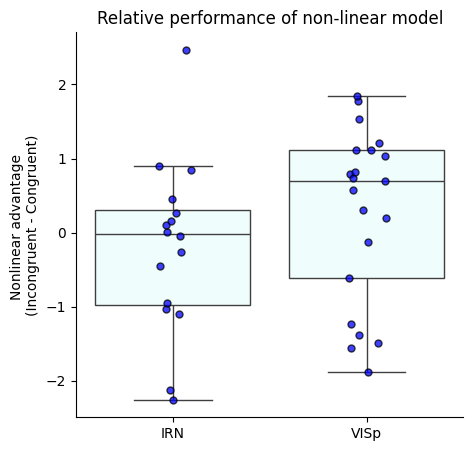

In [168]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot([fm_irn, fm_visp], showfliers=False, ax=ax, color="#eeffff")
sns.stripplot([fm_irn, fm_visp], edgecolor="k", linewidth=1, ax=ax, color="blue", alpha=0.75)
sns.despine(top=True, right=True)
ax.set_xticks(np.arange(2), ["IRN", "VISp"])
ax.set_title("Relative performance of non-linear model")
ax.set_ylabel("Nonlinear advantage \n(Incongruent - Congruent)")

In [3]:
training_sessions = np.asarray([2, 3, 5, 29, 15, 10, 7, 20, 17, 6, 3, 1])
trained_sessions = np.asarray([2, 5, 1, 9, 2, 13, 13, 9, 12, 5, 2, 9])

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Your data
training_sessions = np.asarray([2, 3, 5, 29, 15, 10, 7, 20, 17, 6, 3, 1])
trained_sessions = np.asarray([2, 5, 1, 9, 2, 13, 13, 9, 12, 5, 2, 9])
mice_ids = [f"Mouse {i+1}" for i in range(len(training_sessions))]

# Structure data in a DataFrame

Text(0.5, 1.0, 'Data summary')

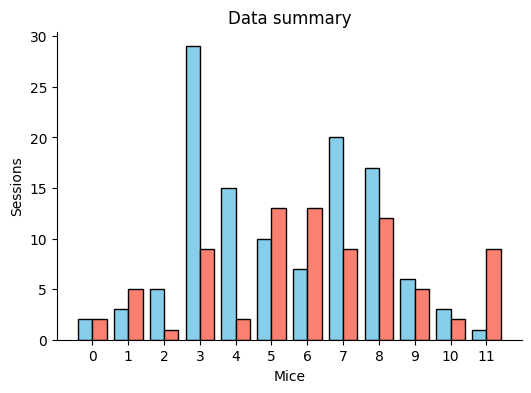

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    np.arange(len(mice_ids)),
    training_sessions,
    width=0.4,
    edgecolor="k",
    color="skyblue",
    label="training",
)
ax.bar(
    np.arange(len(mice_ids)) + 0.4,
    trained_sessions,
    width=0.4,
    edgecolor="k",
    color="salmon",
    label="trained",
)
ax.set_xticks(np.arange(len(mice_ids)) + 0.2, np.arange(len(mice_ids)))
ax.set_xlabel("Mice")
ax.set_ylabel("Sessions")
sns.despine()
ax.set_title("Data summary")

In [23]:
with open("../data/generated/region_wise.pkl", "rb") as f:
    data = pkl.load(f)

In [36]:
data_array_means = []
data_array_stds = []
counts = []
names = []
for k in data.keys():
    fracs = data[k]
    data_array_means.append(np.mean(fracs))
    data_array_stds.append(np.std(fracs))
    counts.append(len(fracs))
    names.append(k)

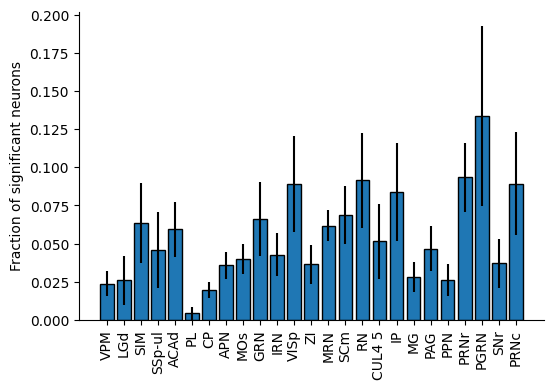

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
plt.bar(
    np.arange(len(data_array_means)),
    data_array_means,
    yerr=data_array_stds / np.sqrt(counts),
    edgecolor="k",
)
ax.set_ylabel("Fraction of significant neurons")    
ax.set_xticks(np.arange(len(counts)), names, rotation=90)
sns.despine()